In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.data_import import load_fashion_mnist, load_olivetti
from src.model import EBM, EnergyHead, EBM_Old
from src.plot import visualize_heads, visualize_head_gradients, visualize_head_abs_gradients, show_grid, show_single_sample
from src.sampler import ReplaySampler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Data
TRAIN_CLASSES = [9]
BS = 32
IMG_SHAPE = (1, 28, 28)
IMG_SHAPE_Olivetti = (1, 64, 64)
# Model
N_HEADS = 3

# Sampler
BUFFER_SIZE = 8
NOISE_FRACTION = 0.05
NOISE_STD = 0.005

In [3]:
train_loader_fmnist, test_loader_fmnist  = load_fashion_mnist(batch_size=BS, class_subset=TRAIN_CLASSES)
train_loader_olivetti, test_loader_olivetti = load_olivetti(batch_size = BS)

In [4]:
model_fm = EBM(image_shape=IMG_SHAPE, n_heads=N_HEADS, batch_size=BS)
model_fm.load_state_dict(torch.load("Models/FMNIST/EBM_10_epochs_(1, 28, 28)_shape_3_heads.pth", map_location=DEVICE, weights_only=False))

model_olivetti = EBM(image_shape=IMG_SHAPE_Olivetti, n_heads=N_HEADS, batch_size=BS)
model_olivetti.load_state_dict(torch.load("Models/OLIVETTI/EBM_10_epochs_(1, 64, 64)_shape_3_heads_1782916208844051426.pth", map_location=DEVICE, weights_only=False))

sampler_fm = ReplaySampler(model=model_fm, img_shape=IMG_SHAPE, buffer_size=BUFFER_SIZE, noise_fraction=NOISE_FRACTION, device=DEVICE)
sampler_olivetti = ReplaySampler(model=model_olivetti, img_shape=IMG_SHAPE_Olivetti, buffer_size=BUFFER_SIZE, noise_fraction=NOISE_FRACTION, device=DEVICE)


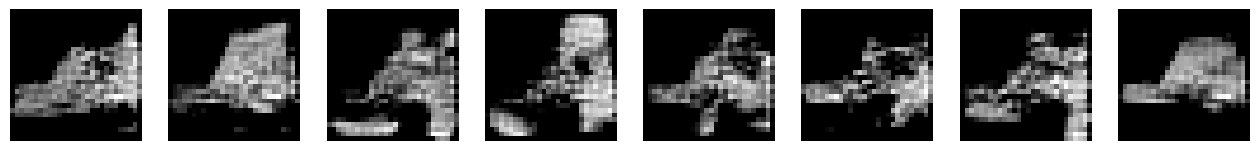

In [8]:
sampler_fm.reset_buffer()
for_grid_fm = sampler_fm.generate(n_samples=200, steps=150)
show_grid(for_grid_fm, cmap="gray")

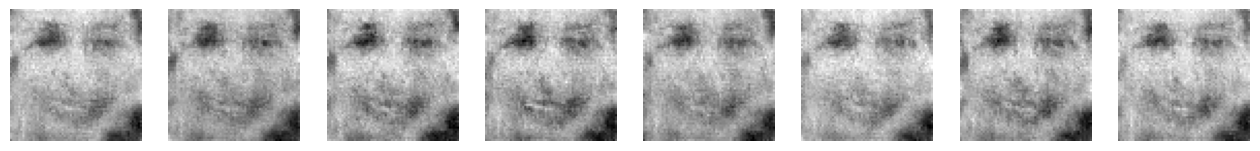

In [9]:
sampler_olivetti.reset_buffer()
for_grid_olivetti = sampler_olivetti.generate(n_samples=30, steps=1000, step_size=10, noise_std=0.005)
show_grid(for_grid_olivetti, cmap="gray")

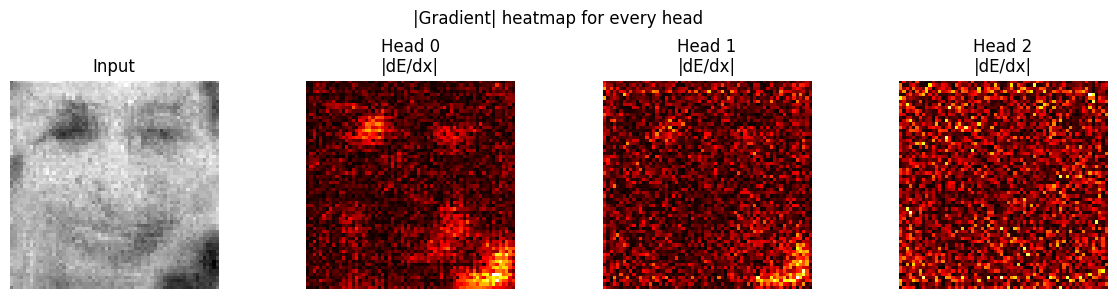

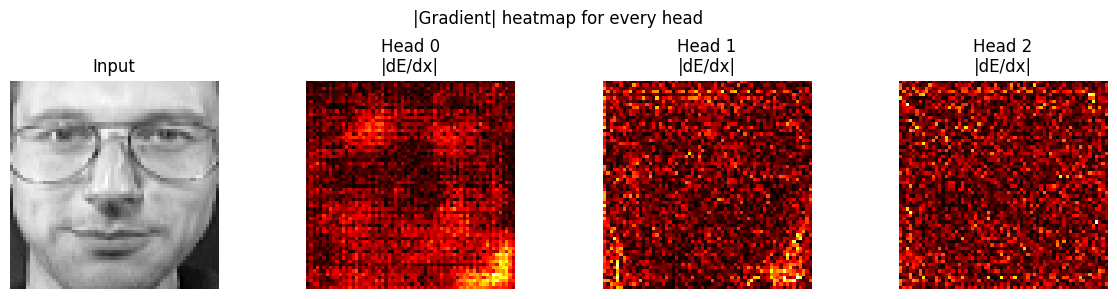

In [17]:

visualize_head_abs_gradients(model_olivetti, for_grid_olivetti, device=DEVICE)
visualize_head_abs_gradients(model_olivetti, next(iter(test_loader_olivetti))[0], device=DEVICE)

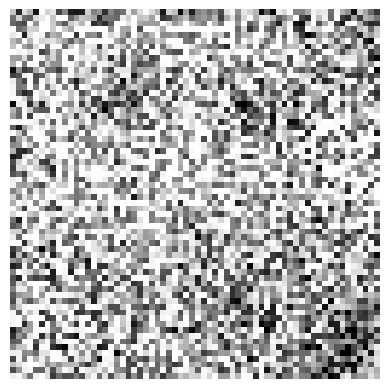

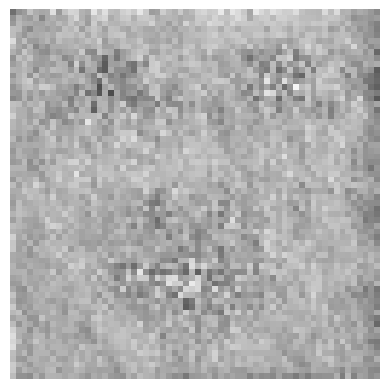

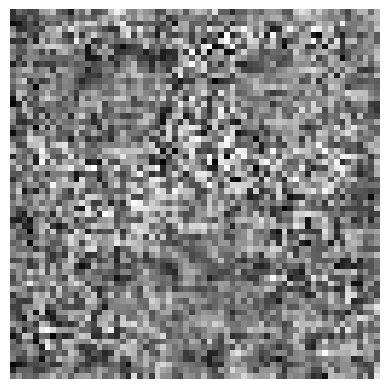

In [21]:
from src.gradient_inspect import synthetize_image_from_head
for i in range(0, 3):
    show_single_sample(synthetize_image_from_head(model_head=model_olivetti.heads[i], n_images=1, img_dimension=64)[0], cmap="gray")

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def tensor_to_numpy_img(x):
    """
    Converte un tensor [1,C,H,W] o [C,H,W] in numpy array pronto per imshow,
    senza aprire figure intermedie.
    """
    x = x.detach().cpu()
    if x.ndim == 4:
        x = x[0]
    if x.ndim == 3:
        x = x.permute(1, 2, 0)
    x = x.clamp(-1, 1).numpy()
    if x.shape[-1] == 1:
        x = x.squeeze(-1)  # grayscale: [H,W] invece di [H,W,1]
    return x

frames = []

# Initial sample
sampler_fm.reset_buffer()
sample = sampler_fm.sample(batch_size=BS, step_size=10.0, noise_std=NOISE_STD, steps=1)
frames.append(tensor_to_numpy_img(sample))

# Sampling loop
for _ in range(60):
    for _ in range(5):
        sample = sampler_fm.langevin_step(x=sample)
    frames.append(tensor_to_numpy_img(sample))

# Create a figure for the animation
fig, ax = plt.subplots()
ax.axis('off')

im = ax.imshow(frames[0], cmap="gray", vmin=-1, vmax=1)  # scala fissa, vedi discussione precedente

def update(frame):
    im.set_array(frame)
    return [im]

ani = FuncAnimation(fig, update, frames=frames, blit=True, interval=200)
ani.save("sampling_animation.gif", writer=PillowWriter(fps=5))
plt.close()


In [9]:
def corrupt_square(img, l, device=None):
    """
    Corrompe un quadrato l x l in posizione random con noise uniforme.
    img: tensor [C, H, W] o [1, C, H, W]
    Ritorna: (img_corrotta, mask) con mask=1 dove il pixel è CORROTTO (da ricostruire)
    """
    device = device or img.device
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.clone().to(device)

    _, C, H, W = img.shape
    assert l < H and l < W, "il quadrato deve essere più piccolo dell'immagine"

    top = torch.randint(0, H - l + 1, (1,)).item()
    left = torch.randint(0, W - l + 1, (1,)).item()

    mask = torch.zeros(1, 1, H, W, device=device)
    mask[:, :, top:top+l, left:left+l] = 1.0

    noise_patch = torch.rand(1, C, l, l, device=device) * 2 - 1  # noise in [-1, 1]
    img_corrupt = img.clone()
    img_corrupt[:, :, top:top+l, left:left+l] = noise_patch

    return img_corrupt, mask

def reconstruct_masked(model, img_corrupt, mask, steps=200, step_size=10.0,
                        noise_std=0.005, grad_clip=0.03, device=None):
    """
    Langevin sampling che aggiorna SOLO i pixel dove mask==1,
    lasciando il resto identico all'immagine corrotta in input.
    """
    device = device or next(model.parameters()).device
    was_training = model.training
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    x = img_corrupt.clone().to(device)
    original = img_corrupt.clone().to(device)  # parte non corrotta da preservare
    mask = mask.to(device)

    for _ in range(steps):
        x = x.detach()
        noise = torch.randn_like(x) * noise_std
        x = (x + noise * mask).clamp(-1.0, 1.0)  # noise solo dove serve

        with torch.enable_grad():
            x.requires_grad_(True)
            energy = model(x)[0].sum()
            grad = torch.autograd.grad(energy, x, only_inputs=True)[0]

        grad = grad.detach().clamp(-grad_clip, grad_clip)
        x = (x.detach() - step_size * grad * mask).clamp(-1.0, 1.0)  # update solo mascherato

        # forza i pixel non corrotti a restare esattamente uguali all'originale
        x = x * mask + original * (1 - mask)

    for p in model.parameters():
        p.requires_grad_(True)
    model.train(was_training)

    return x

def corrupt_salt_pepper(img, amount=0.1, device=None):
    """
    Aggiunge salt & pepper noise su tutta l'immagine.
    amount: frazione di pixel corrotti (es 0.1 = 10%)
    """
    device = device or img.device
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.clone().to(device)

    _, C, H, W = img.shape
    img_corrupt = img.clone()

    rand = torch.rand(1, 1, H, W, device=device)
    salt_mask = (rand < amount / 2)
    pepper_mask = (rand > 1 - amount / 2)

    img_corrupt[salt_mask.expand(-1, C, -1, -1)] = 1.0   # salt = bianco
    img_corrupt[pepper_mask.expand(-1, C, -1, -1)] = -1.0  # pepper = nero

    return img_corrupt

def denoise_langevin(model, img_corrupt, steps=200, step_size=10.0,
                      noise_std=0.005, grad_clip=0.03, device=None):
    """
    Langevin sampling classico partendo dall'immagine rumorosa
    invece che da puro noise. Nessuna maschera: tutta l'immagine è libera di evolvere.
    """
    device = device or next(model.parameters()).device
    was_training = model.training
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    x = img_corrupt.clone().to(device)

    for _ in range(steps):
        x = x.detach()
        noise = torch.randn_like(x) * noise_std
        x = (x + noise).clamp(-1.0, 1.0)

        with torch.enable_grad():
            x.requires_grad_(True)
            energy = model(x)[0].sum()
            grad = torch.autograd.grad(energy, x, only_inputs=True)[0]

        grad = grad.detach().clamp(-grad_clip, grad_clip)
        x = (x.detach() - step_size * grad).clamp(-1.0, 1.0)

    for p in model.parameters():
        p.requires_grad_(True)
    model.train(was_training)

    return x

def plot_reconstruction_demo(model, img, l=10, amount=0.15, steps=200,
                              step_size=10.0, noise_std=0.005, grad_clip=0.03,
                              device=None, cmap="gray"):
    """
    Mostra in un'unica figura:
    - immagine originale
    - inpainting: corrotta (quadrato) vs ricostruita
    - denoising: corrotta (salt&pepper) vs ricostruita
    Con l'energia E(x) del modello sotto ogni immagine.

    img: tensor [C, H, W] o [1, C, H, W]
    """
    device = device or next(model.parameters()).device
    if img.dim() == 3:
        img = img.unsqueeze(0)
    img = img.to(device)

    # --- Inpainting ---
    img_square, mask = corrupt_square(img, l=l, device=device)
    img_reconstructed = reconstruct_masked(
        model, img_square, mask, steps=steps, step_size=step_size,
        noise_std=noise_std, grad_clip=grad_clip, device=device
    )

    # --- Denoising ---
    img_sp = corrupt_salt_pepper(img, amount=amount, device=device)
    img_denoised = denoise_langevin(
        model, img_sp, steps=steps, step_size=step_size,
        noise_std=noise_std, grad_clip=grad_clip, device=device
    )

    # --- Calcolo energie ---
    def get_energy(x):
        model.eval()
        with torch.no_grad():
            e, _ = model(x)
        return e.sum().item()  # scalare, somma nel caso ci fossero più elementi/head

    imgs = [img, img_square, img_reconstructed, img_sp, img_denoised]
    titles = ["Original", "Corrupted", "Reconstructed\n(inpainting)",
              "Corrupted\n(salt & pepper noise)", "Reconstructed\n(denoising)"]
    energies = [get_energy(im) for im in imgs]

    # --- Plot ---
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))

    for ax, im, title, e in zip(axes, imgs, titles, energies):
        im_np = im[0].detach().cpu().clamp(-1, 1)
        if im_np.shape[0] == 1:
            im_np = im_np.squeeze(0)
        else:
            im_np = im_np.permute(1, 2, 0)

        ax.imshow(im_np, cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        ax.text(0.5, -0.08, f"E = {e:.4g}", transform=ax.transAxes,
                 ha="center", va="top", fontsize=10)

    plt.tight_layout()
    plt.show()

    return {
        "original": img,
        "corrupted_square": img_square,
        "reconstructed": img_reconstructed,
        "mask": mask,
        "corrupted_salt_pepper": img_sp,
        "denoised": img_denoised,
        "energies": dict(zip(titles, energies)),
    }

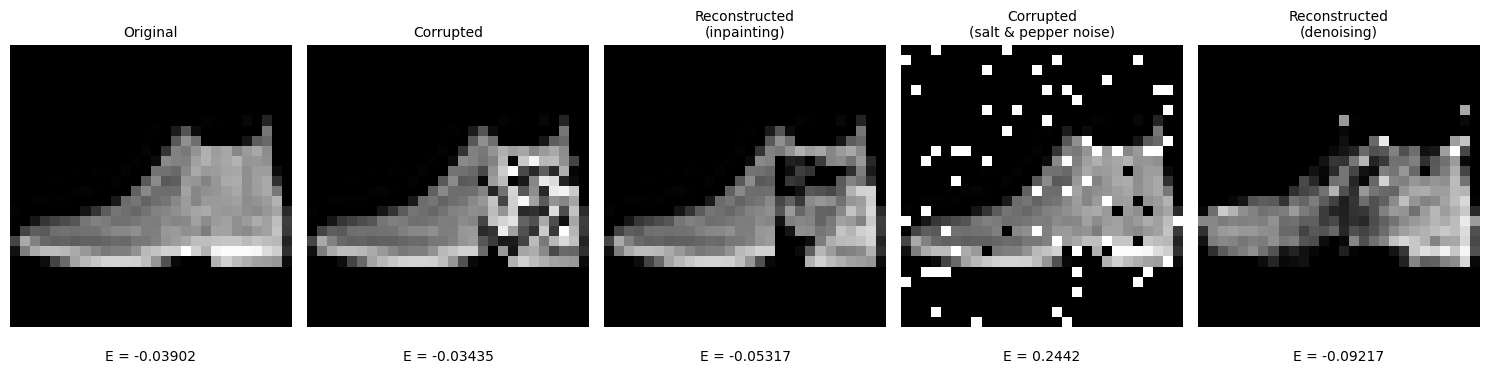

In [10]:
# Prendi un singolo batch dal loader
data_iter = iter(test_loader_fmnist) 
batch, labels = next(data_iter)

img = batch[0:1].to(DEVICE)  # [1, C, H, W], stesso formato di prima

results = plot_reconstruction_demo(model_fm, img, l=10, amount=0.15, steps=200, device=DEVICE, step_size=10)


In [18]:
from src.diagnostic import mean_energy, nearest_neighbor_distance
def nearest_neighbor_distance(generated, train_loader, n_samples=1000, device=None):
    """
    Check the distance between a set generated from the model and training points.
    If the distance goes to zero, the model may be overfitting by generating
    samples really close to data points.

    generated: tensor [n_gen, C, H, W]
    train_loader: DataLoader da cui pescare i sample di training
    n_samples: numero di sample di training da usare per il confronto
    """
    device = device or generated.device

    # Pesca n_samples dal loader
    train_data = []
    n_collected = 0
    for x, _ in train_loader:
        train_data.append(x)
        n_collected += x.size(0)
        if n_collected >= n_samples:
            break

    train_data = torch.cat(train_data, dim=0)[:n_samples].to(device)

    gen_flat = generated.view(generated.size(0), -1)
    train_flat = train_data.view(train_data.size(0), -1)

    dists = torch.cdist(gen_flat, train_flat)  # [n_gen, n_train]
    min_dists, min_idx = dists.min(dim=1)

    return min_dists, min_idx

_ = mean_energy(model=model_fm, train_loader=train_loader_fmnist, test_loader=test_loader_fmnist, n_batches=10, device=DEVICE)
_ = nearest_neighbor_distance(generated=for_grid, train_loader = train_loader_fmnist, device=DEVICE)

_

E_train=0.09227, E_val=0.08204, gap=-0.01023


(tensor([11.7928, 11.5303, 11.8891, 10.4309, 10.9761, 11.1874, 11.1723, 10.7732,
         10.7818, 11.0883, 11.1962, 11.3748, 10.7300, 11.2381, 10.7552, 11.1920,
         11.2121, 10.8433, 11.1735, 11.1669, 11.2207, 11.0751, 10.7716, 11.1953,
         11.1939, 10.7457, 11.1172, 11.1903, 11.3507, 11.1199, 11.1236, 11.2553,
         11.1508, 10.2754, 11.3289, 11.1076, 11.3655, 11.4108, 11.3026, 11.2035,
         11.3213, 11.3895, 11.4082, 11.4062, 10.7089, 11.1677, 11.2975, 11.1958,
         11.2332, 10.7036, 11.3194, 10.7333, 11.3732, 11.2765, 10.7184, 11.2388,
         10.7820, 10.7035, 11.3425, 10.2754, 10.3410, 10.7879, 11.2281, 11.3684,
         11.1346, 11.1816, 11.3487, 11.1538, 11.3378, 11.4004, 10.4324, 11.3793,
         10.7258, 10.2132, 10.2348, 10.8219, 10.8656, 11.4051, 10.7078, 11.1965,
         10.3053, 11.0882, 10.7972, 11.2185, 10.3633, 11.1503, 11.4184, 11.2341,
         11.2211, 10.7571, 11.1245, 10.3366, 11.0824, 11.1744, 11.4095, 11.2981,
         11.2150, 10.3677, 1